# Netflix Customer Churn Analysis
**Tools:** Python, pandas, matplotlib, seaborn, SQLite, scikit-learn  
**Dataset:** Netflix customer data with subscription, engagement, and demographic details  
**Goal:** Identify key factors driving customer churn and predict which customers are likely to leave

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

In [2]:
df = pd.read_csv('netflix_customer_churn.csv')

print("Shape:", df.shape)
print("\nColumn names:\n", df.columns.tolist())
print("\nMissing values:\n", df.isnull().sum())
print("\nChurn distribution:\n", df['churned'].value_counts())
df.head()

Shape: (5000, 14)

Column names:
 ['customer_id', 'age', 'gender', 'subscription_type', 'watch_hours', 'last_login_days', 'region', 'device', 'monthly_fee', 'churned', 'payment_method', 'number_of_profiles', 'avg_watch_time_per_day', 'favorite_genre']

Missing values:
 customer_id               0
age                       0
gender                    0
subscription_type         0
watch_hours               0
last_login_days           0
region                    0
device                    0
monthly_fee               0
churned                   0
payment_method            0
number_of_profiles        0
avg_watch_time_per_day    0
favorite_genre            0
dtype: int64

Churn distribution:
 churned
1    2515
0    2485
Name: count, dtype: int64


,customer_id,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,churned,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre
0,a9b75100-82a8-427a-a208-72f24052884a,51,Other,Basic,14.73,29,Africa,TV,8.99,1,Gift Card,1,0.49,Action
1,49a5dfd9-7e69-4022-a6ad-0a1b9767fb5b,47,Other,Standard,0.70,19,Europe,Mobile,13.99,1,Gift Card,5,0.03,Sci-Fi
2,4d71f6ce-fca9-4ff7-8afa-197ac24de14b,27,Female,Standard,16.32,10,Asia,TV,13.99,0,Crypto,2,1.48,Drama
3,d3c72c38-631b-4f9e-8a0e-de103cad1a7d,53,Other,Premium,4.51,12,Oceania,TV,17.99,1,Crypto,2,0.35,Horror
4,4e265c34-103a-4dbb-9553-76c9aa47e946,56,Other,Standard,1.89,13,Africa,Mobile,13.99,1,Crypto,2,0.13,Action


In [3]:
# Convert churned to readable labels for charts
df['churn_label'] = df['churned'].map({1: 'Churned', 0: 'Retained'})

# Check data types
print("Data types:\n", df.dtypes)
print("\nSubscription types:", df['subscription_type'].unique())
print("Regions:", df['region'].unique())
print("Devices:", df['device'].unique())

Data types:
 customer_id                object
age                         int64
gender                     object
subscription_type          object
watch_hours               float64
last_login_days             int64
region                     object
device                     object
monthly_fee               float64
churned                     int64
payment_method             object
number_of_profiles          int64
avg_watch_time_per_day    float64
favorite_genre             object
churn_label                object
dtype: object

Subscription types: ['Basic' 'Standard' 'Premium']
Regions: ['Africa' 'Europe' 'Asia' 'Oceania' 'South America' 'North America']
Devices: ['TV' 'Mobile' 'Laptop' 'Desktop' 'Tablet']


In [4]:
conn = sqlite3.connect(':memory:')
df.to_sql('netflix', conn, if_exists='replace', index=False)

# Q1: Which subscription type churns the most?
q1 = pd.read_sql("""
    SELECT subscription_type,
           COUNT(*) AS total_customers,
           SUM(churned) AS total_churned,
           ROUND(SUM(churned) * 100.0 / COUNT(*), 2) AS churn_rate_pct
    FROM netflix
    GROUP BY subscription_type
    ORDER BY churn_rate_pct DESC
""", conn)
print("Churn Rate by Subscription Type:")
print(q1)

Churn Rate by Subscription Type:
  subscription_type  total_customers  total_churned  churn_rate_pct
0             Basic             1661           1027           61.83
1          Standard             1646            748           45.44
2           Premium             1693            740           43.71


In [5]:
q2 = pd.read_sql("""
    SELECT region,
           COUNT(*) AS total_customers,
           SUM(churned) AS total_churned,
           ROUND(SUM(churned) * 100.0 / COUNT(*), 2) AS churn_rate_pct
    FROM netflix
    GROUP BY region
    ORDER BY churn_rate_pct DESC
""", conn)
print("Churn Rate by Region:")
print(q2)

Churn Rate by Region:
          region  total_customers  total_churned  churn_rate_pct
0         Europe              867            448           51.67
1  South America              873            449           51.43
2           Asia              841            426           50.65
3        Oceania              765            383           50.07
4  North America              851            421           49.47
5         Africa              803            388           48.32


In [6]:
q3 = pd.read_sql("""
    SELECT device,
           COUNT(*) AS total_customers,
           SUM(churned) AS total_churned,
           ROUND(SUM(churned) * 100.0 / COUNT(*), 2) AS churn_rate_pct
    FROM netflix
    GROUP BY device
    ORDER BY churn_rate_pct DESC
""", conn)
print("Churn Rate by Device:")
print(q3)

Churn Rate by Device:
    device  total_customers  total_churned  churn_rate_pct
0   Laptop             1006            521           51.79
1   Mobile             1004            507           50.50
2   Tablet             1048            524           50.00
3       TV              993            496           49.95
4  Desktop              949            467           49.21


In [7]:
q4 = pd.read_sql("""
    SELECT churn_label,
           ROUND(AVG(watch_hours), 2) AS avg_watch_hours,
           ROUND(AVG(last_login_days), 2) AS avg_days_since_login,
           ROUND(AVG(avg_watch_time_per_day), 2) AS avg_daily_watch_time,
           ROUND(AVG(monthly_fee), 2) AS avg_monthly_fee
    FROM netflix
    GROUP BY churn_label
""", conn)
print("Behavior: Churned vs Retained:")
print(q4)

Behavior: Churned vs Retained:
  churn_label  avg_watch_hours  avg_days_since_login  avg_daily_watch_time  \
0     Churned             5.92                 38.31                  0.16   
1    Retained            17.45                 21.77                  1.59   

   avg_monthly_fee  
0            13.13  
1            14.25  


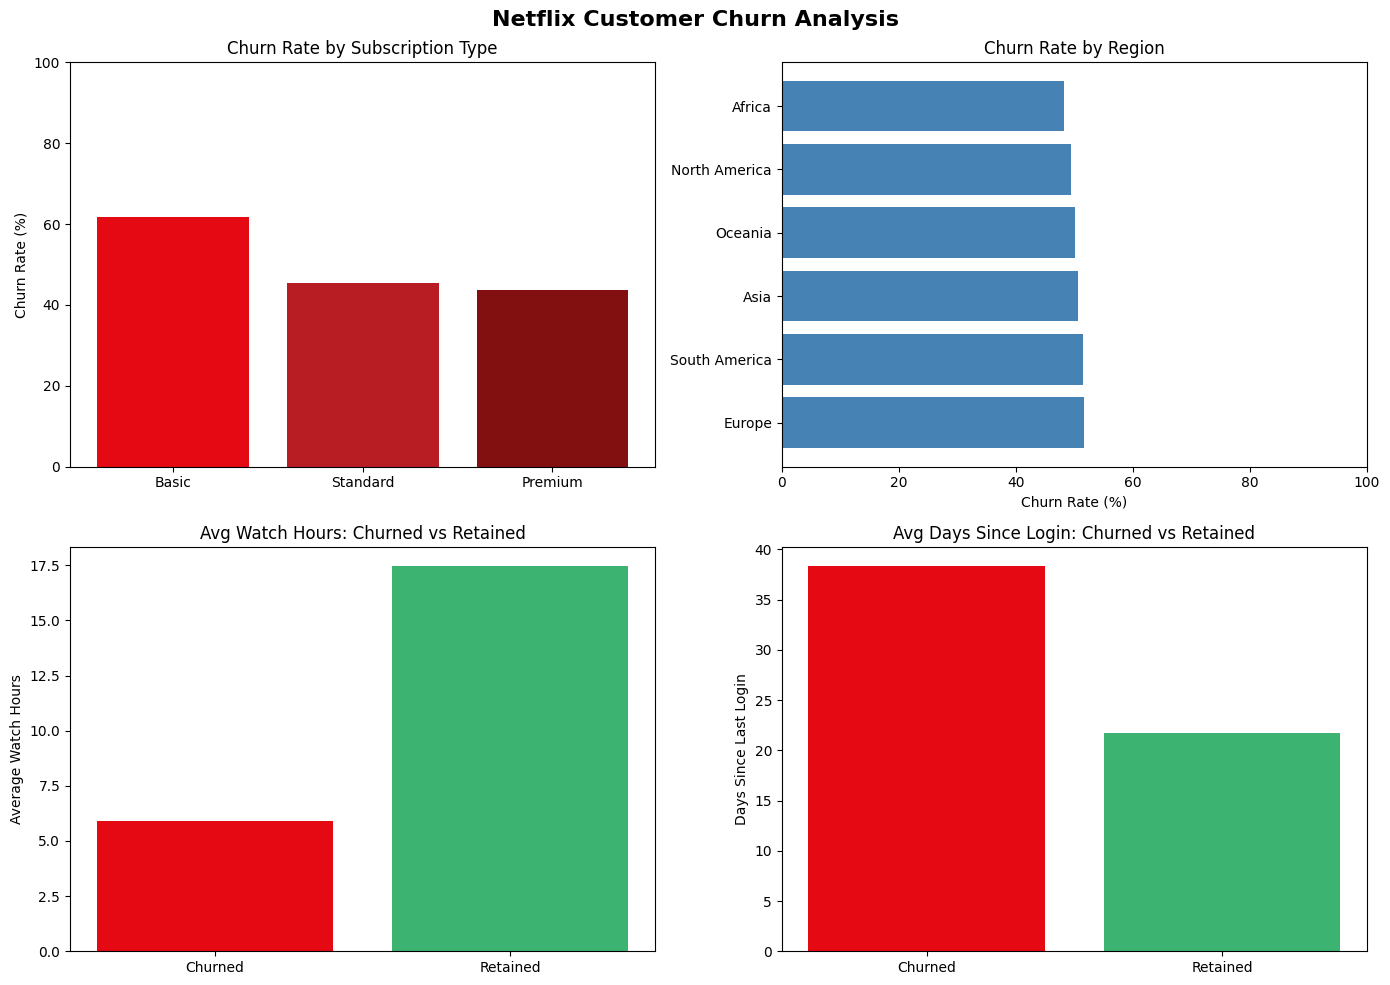

Chart saved ✅


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Netflix Customer Churn Analysis', fontsize=16, fontweight='bold')

# Chart 1: Churn rate by subscription type
axes[0,0].bar(q1['subscription_type'], q1['churn_rate_pct'], color=['#E50914', '#B81D24', '#831010'])
axes[0,0].set_title('Churn Rate by Subscription Type')
axes[0,0].set_ylabel('Churn Rate (%)')
axes[0,0].set_ylim(0, 100)

# Chart 2: Churn rate by region
axes[0,1].barh(q2['region'], q2['churn_rate_pct'], color='steelblue')
axes[0,1].set_title('Churn Rate by Region')
axes[0,1].set_xlabel('Churn Rate (%)')
axes[0,1].set_xlim(0, 100)

# Chart 3: Avg watch hours churned vs retained
axes[1,0].bar(q4['churn_label'], q4['avg_watch_hours'], color=['#E50914', 'mediumseagreen'])
axes[1,0].set_title('Avg Watch Hours: Churned vs Retained')
axes[1,0].set_ylabel('Average Watch Hours')

# Chart 4: Avg days since login churned vs retained
axes[1,1].bar(q4['churn_label'], q4['avg_days_since_login'], color=['#E50914', 'mediumseagreen'])
axes[1,1].set_title('Avg Days Since Login: Churned vs Retained')
axes[1,1].set_ylabel('Days Since Last Login')

plt.tight_layout()
plt.savefig('netflix_churn_analysis.png', dpi=150)
plt.show()
print("Chart saved ✅")

In [9]:
from sklearn.preprocessing import LabelEncoder

# Encode categorical columns for the model
df_model = df.copy()
cat_cols = ['gender', 'subscription_type', 'region', 'device', 'payment_method', 'favorite_genre']

le = LabelEncoder()
for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col])

# Define features and target
X = df_model[['age', 'subscription_type', 'watch_hours', 'last_login_days', 
               'monthly_fee', 'number_of_profiles', 'avg_watch_time_per_day']]
y = df_model['churned']

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")

Training set size: 4000
Test set size: 1000


In [11]:
# Train the logistic regression model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Test the model
y_pred = model.predict(X_test)

# Print results
print("Model Accuracy:", round(model.score(X_test, y_test) * 100, 2), "%")
print("\nDetailed Report:")
print(classification_report(y_test, y_pred, target_names=['Retained', 'Churned']))

Model Accuracy: 88.1 %

Detailed Report:
              precision    recall  f1-score   support

    Retained       0.89      0.87      0.88       498
     Churned       0.87      0.89      0.88       502

    accuracy                           0.88      1000
   macro avg       0.88      0.88      0.88      1000
weighted avg       0.88      0.88      0.88      1000



## Key Findings

1. **Subscription Type is the strongest churn driver:** Basic plan customers 
churn at 61.83%, nearly 20 percentage points higher than Standard (45.44%) 
and Premium (43.71%) subscribers

2. **Low engagement predicts churn:** Churned customers average only 5.92 watch 
hours vs 17.45 hours for retained customers — nearly 3x lower engagement

3. **Inactivity is a red flag:** Churned customers last logged in 38 days ago 
on average vs 21 days for retained customers

4. **Region and device have minimal impact:** Churn rates are consistent across 
all 6 regions (48-51%) and all 5 devices, suggesting these are not key drivers

5. **Prediction model:** Logistic regression model achieved 88.1% accuracy 
predicting churn using engagement and subscription features

## Recommendations
- **Target Basic plan users** with upgrade offers or loyalty incentives 
before they churn
- **Flag customers inactive for 30+ days** for re-engagement campaigns
- **Monitor watch hours** as an early warning signal — dropping below 
6 hours is a strong churn indicator